# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [19]:
print(df.columns)

Index(['type', 'release_year', 'added_year', 'genre', 'country', 'rating',
       'duration', 'decade'],
      dtype='object')


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


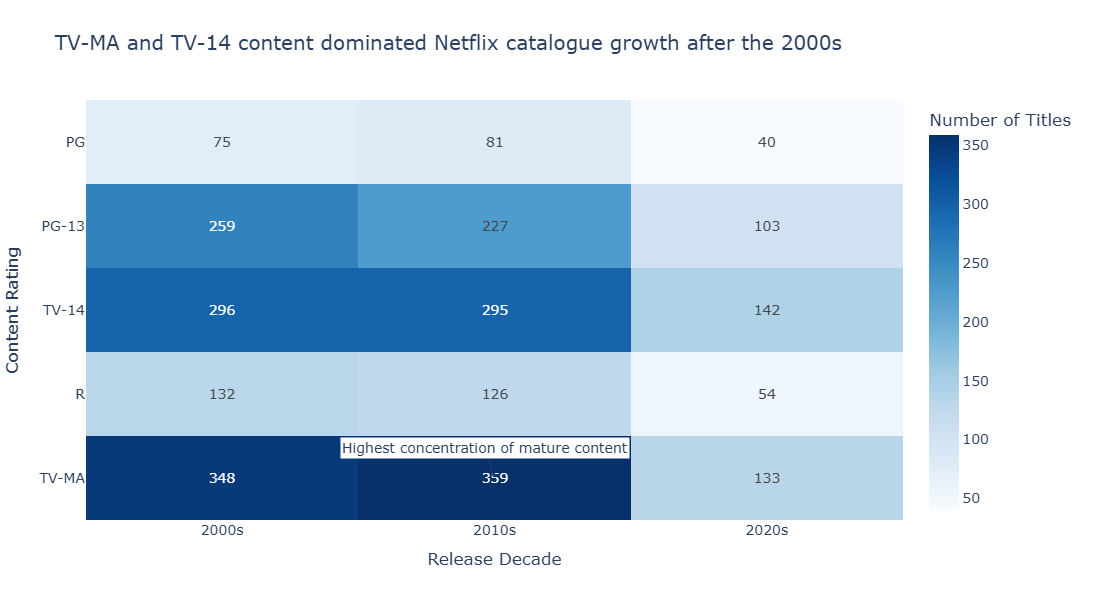

In [16]:
import pandas as pd
import plotly.express as px


# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'


# Filter required ratings
ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

filtered = df[df['rating'].isin(ratings_filter)].copy()

# Group data properly
heatmap_data = filtered.groupby(
    ['rating', 'decade']
).size().reset_index(name='count')

# Pivot table
pivot = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Logical rating order
rating_order = ['PG', 'PG-13', 'TV-14', 'R', 'TV-MA']

pivot = pivot.reindex(rating_order)

# Create heatmap
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',
    text_auto=True,
    aspect='auto',
    title='TV-MA and TV-14 content dominated Netflix catalogue growth after the 2000s'
)

# Layout styling
fig.update_layout(
    width=1000,
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14),
    title_font=dict(size=20),
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    coloraxis_colorbar=dict(title='Number of Titles')
)

# Annotation
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration of mature content',
    showarrow=True,
    arrowhead=2,
    bgcolor='white'
)

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


   added_year  count
0        2015     71
1        2016     93
2        2017     77
3        2018     79
4        2019     93
5        2020     81
6        2021     83
7        2022     82


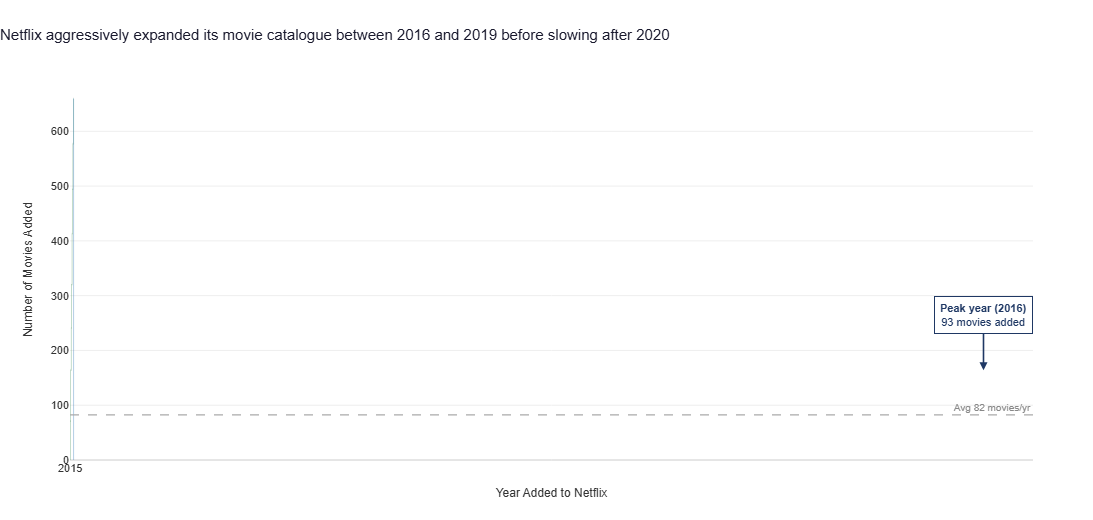

In [2]:
# ── Task 2: Waterfall — Movie additions per year 2015–2022 ────────────────────

movies = df[df['type'] == 'Movie']

adds = (
    movies
    .groupby('added_year')
    .size()
    .reset_index(name='count')
)
adds = adds[(adds['added_year'] >= 2015) & (adds['added_year'] <= 2022)].copy()
adds = adds.sort_values('added_year').reset_index(drop=True)

print(adds)  # sanity check

# ── Derived values ────────────────────────────────────────────────────────────
cumulative  = adds['count'].cumsum().tolist()
grand_total = int(adds['count'].sum())
avg_annual  = adds['count'].mean()

# Peak year — data-driven, never hardcoded
peak_idx       = int(adds['count'].idxmax())
peak_year      = str(int(adds.loc[peak_idx, 'added_year']))
peak_count     = int(adds.loc[peak_idx, 'count'])
peak_cumtotal  = int(cumulative[peak_idx])   # top of the peak bar in the waterfall

# ── Arrays ────────────────────────────────────────────────────────────────────
x_vals  = adds['added_year'].astype(int).astype(str).tolist() + ['Total\n2015–2022']

y_vals  = adds['count'].tolist() + [0]

measure = ['relative'] * len(adds) + ['total']

text_labels = [f'{v:,}' for v in adds['count']] + [f'{grand_total:,}']

# ── Waterfall trace ───────────────────────────────────────────────────────────
trace = go.Waterfall(
    x            = x_vals,          # string labels directly — no tickvals override needed
    y            = y_vals,
    measure      = measure,
    text         = text_labels,     # yearly increment shown on each bar
    textposition = 'outside',
    textfont     = dict(family='Arial', size=11, color='#333333'),
    connector    = dict(line=dict(color='#BBBBBB', dash='dot', width=1.2)),
    increasing   = dict(marker=dict(color='#5B9E6F')),   # calm green — additions
    totals       = dict(marker=dict(color='#2E75B6')),   # steel blue — total bar
    hovertemplate= '<b>%{x}</b><br>Added this year: %{y:,}<extra></extra>',
)

fig = go.Figure(data=[trace])

# ── Annotation on peak bar ───────────────────────────────────────────────

fig.add_annotation(
    x          = peak_year,
    y          = peak_cumtotal,      # ← top of the bar in waterfall y-space
    text       = f'<b>Peak year ({peak_year})</b><br>{peak_count:,} movies added',
    showarrow  = True,
    arrowhead  = 2,
    arrowcolor = '#1F3864',
    arrowwidth = 1.6,
    ax=0, ay=-55,
    font       = dict(family='Arial', size=11, color='#1F3864'),
    bgcolor    = 'rgba(255,255,255,0.88)',
    bordercolor= '#1F3864',
    borderwidth= 1,
    borderpad  = 5,
    align      = 'center',
)

# ── Average reference line ────────────────────────────────────────────────────
fig.add_hline(
    y                   = avg_annual,
    line_dash           = 'dash',
    line_color          = '#AAAAAA',
    line_width          = 1.2,
    annotation_text     = f'Avg {avg_annual:.0f} movies/yr',
    annotation_position = 'top right',
    annotation_font     = dict(family='Arial', size=10, color='#888888'),
)

# ── Layout ────────────────────────────────────────────────────────────────────

fig.update_layout(
    title=dict(
        text    = ('Netflix aggressively expanded its movie catalogue '
                   'between 2016 and 2019 before slowing after 2020'),
        font    = dict(family='Arial', size=15, color='#1A1A2E'),
        x       = 0.0,
        xanchor = 'left',
    ),
    font          = dict(family='Arial', size=12, color='#333333'),
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    showlegend    = False,
    height        = 520,
    width         = 860,
    margin        = dict(l=70, r=60, t=80, b=60),
    xaxis=dict(
        title    = dict(text='Year Added to Netflix', font=dict(size=12)),
        tickfont = dict(size=11),
        showgrid = False,
        zeroline = False,
    ),
    yaxis=dict(
        title    = dict(text='Number of Movies Added', font=dict(size=12)),
        tickfont = dict(size=11),
        gridcolor= '#EEEEEE',
        zeroline = True,
        zerolinecolor ='#CCCCCC',
        zerolinewidth = 1,
        rangemode= 'tozero',    # enforces zero baseline per SWD rule
    ),
)

fig.show()